# EDiSS: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/EDiSS](https://github.com/Mishrakshitij/EDiSS)   
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'EDiSS'
COMMIT = '3fd849ed85ac924b9243ac0d58d498e694773776'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: 3fd849ed85ac924b9243ac0d58d498e694773776
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


### Compatibility with the repository requirements
The table checks installed versions against the base dependencies and optional dependency groups used by this experiment.

In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,"torch>=2.3,<3",2.13.0+cu129,True
1,"transformers>=4.45,<6",4.57.6,True
2,"peft>=0.13,<1",0.18.1,True
3,"accelerate>=1,<2",1.14.0,True
4,numpy>=1.24,2.3.5,True
5,safetensors>=0.4,0.8.0,True
6,"matplotlib>=3.7,<4",3.10.7,True


PASS: Python and all dependencies declared for the tested paths are compatible.


# EDiSS: repository executability study
This notebook checks the repository's supervised DSS learning pathway using
the released PDCare data and downloaded `sshleifer/tiny-gpt2` weights. It runs
five LoRA optimizer updates, saves and reloads the native checkpoint, and
evaluates four held-out examples. The paper's Phi-3-small backbone, reward
classifiers, and PPO pipeline are separate configurations outside this check.

In [ ]:
import importlib.metadata as metadata
from itertools import islice
from collections import Counter
import csv
import json
import math
from pathlib import Path
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import torch
from torch.optim.optimizer import register_optimizer_step_post_hook

sys.path.insert(0, str(REPO_ROOT / "src"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from ediss.data import iter_response_examples, read_rows, verify_release
from ediss.models import create_causal_lm, load_causal_lm
from ediss.training import TrainConfig, seed_everything, train_sft, evaluate_supervised
from ediss.generation import generate_responses

COMMIT = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()
VERSIONS = {name: metadata.version(name) for name in ("torch", "transformers", "peft", "numpy", "pandas", "matplotlib")}
print("Repository: Mishrakshitij/EDiSS | revision:", COMMIT)
print("Backbone:", CAUSAL_MODEL, "| device:", DEVICE)
display(pd.Series(VERSIONS, name="Installed version").to_frame())

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: Mishrakshitij/EDiSS | revision: 3fd849ed85ac924b9243ac0d58d498e694773776
Backbone: sshleifer/tiny-gpt2 | device: cuda


,Installed version
torch,2.13.0+cu129
transformers,4.57.6
peft,0.18.1
numpy,2.3.5
pandas,3.0.5
matplotlib,3.10.7


## Dataset integrity and exploratory analysis
Native verification checks the manifest checksums, CSV rows, label IDs, and
split separation. Class-frequency plots describe the complete released
dataset, and training selections use its native response-example iterator.

,utterances,conversations
split,,
train,125022,5436
validation,15536,681
test,15533,679


Integrity: PASS | utterances: 156091 | dialogues: 6796


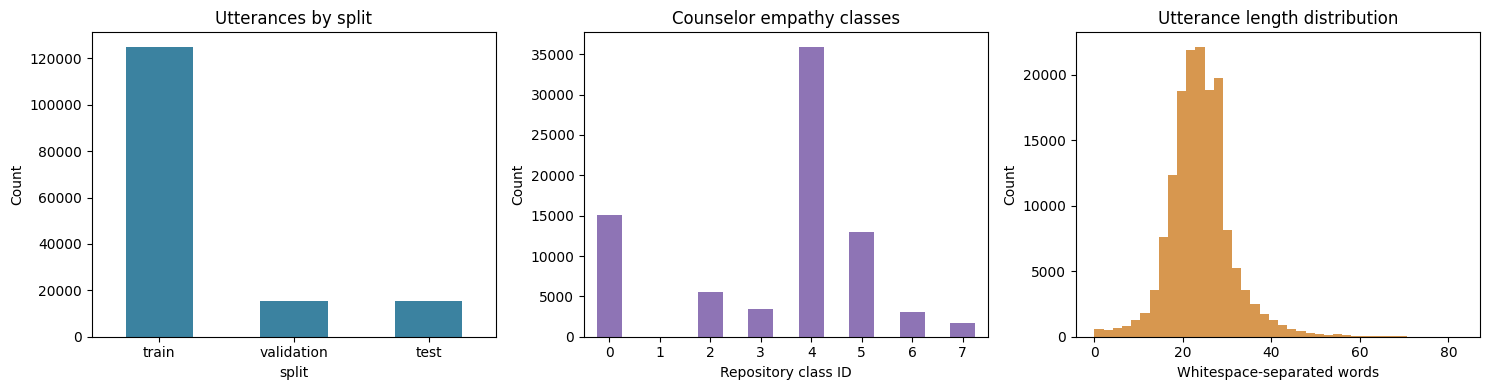

In [ ]:
DATA = REPO_ROOT / "datasets"
integrity = verify_release(DATA)
assert integrity["valid"]
split_counts = Counter()
conversation_ids = {}
missing = Counter()
word_lengths = []
for row in read_rows(DATA):
    split_counts[row["split"]] += 1
    conversation_ids.setdefault(row["split"], set()).add(row["Convo_id"])
    missing.update(key for key, value in row.items() if not value.strip())
    word_lengths.append(len(row["Utterance"].split()))
split_table = pd.DataFrame([{"split": split, "utterances": split_counts[split],
    "conversations": len(conversation_ids[split])} for split in ("train", "validation", "test")]).set_index("split")
display(split_table)
print("Integrity: PASS | utterances:", integrity["utterances"], "| dialogues:", integrity["dialogues"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
split_table["utterances"].plot.bar(ax=axes[0], color="#3b82a0", rot=0, title="Utterances by split")
pd.Series(integrity["labels"]["empathy_label"]).plot.bar(ax=axes[1], color="#8e74b5", rot=0,
    title="Counselor empathy classes")
axes[1].set_xlabel("Repository class ID")
axes[2].hist(word_lengths, bins=40, color="#d7974f")
axes[2].set_title("Utterance length distribution")
axes[2].set_xlabel("Whitespace-separated words")
for axis in axes:
    axis.set_ylabel("Count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset-overview.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
train_examples = list(islice(iter_response_examples(DATA, "train", history_turns=4), 10))
validation_examples = list(islice(iter_response_examples(DATA, "validation", history_turns=4), 4))
test_examples = list(islice(iter_response_examples(DATA, "test", history_turns=4), 4))
assert len(train_examples) == 10 and len(validation_examples) == len(test_examples) == 4
assert {x["dialogue_id"] for x in train_examples}.isdisjoint(x["dialogue_id"] for x in test_examples)
display(pd.DataFrame([{"split": split, "selected responses": len(rows)} for split, rows in
    (("train", train_examples), ("validation", validation_examples), ("test", test_examples))]))
display(pd.DataFrame([{"example_id": x["id"], "prompt excerpt": x["prompt"][:240],
                       "reference excerpt": x["response"][:240]} for x in train_examples[:3]]))

,split,selected responses
0,train,10
1,validation,4
2,test,4


,example_id,prompt excerpt,reference excerpt
0,1_2,"Provide an empathetic, respectful disability-s...",Hello! I'm here to help. Traveling with mobili...
1,1_4,"Provide an empathetic, respectful disability-s...",Certainly! Researching accessible transportati...
2,1_6,"Provide an empathetic, respectful disability-s...",Absolutely! Contact the airline in advance to ...


## Native model loading and five supervised updates
The repository model factory downloads the small causal backbone and attaches
LoRA adapters. Its own response-only loss, optimizer loop, validation function,
and checkpoint writer are used below. A post-step hook counts completed
optimizer updates independently of the returned training statistics.

In [ ]:
CHECKPOINT = OUTPUT_DIR / "checkpoint"
seed_everything(42)
model, tokenizer = create_causal_lm(CAUSAL_MODEL, device=DEVICE, dtype="float32",
    use_lora=True, lora_rank=2, lora_alpha=4, lora_dropout=0.0, lora_target_modules=["c_attn"])
parameter_count = sum(p.numel() for p in model.parameters())
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
config = TrainConfig(epochs=1, batch_size=2, learning_rate=5e-4, max_length=96,
                     max_steps=5, device=DEVICE, seed=42)
print("Model loaded | total parameters:", parameter_count, "| trainable:", trainable_parameters)
observed_steps = []
step_hook = register_optimizer_step_post_hook(lambda *args, **kwargs: observed_steps.append(len(observed_steps) + 1))
started = time.perf_counter()
try:
    training = train_sft(model, tokenizer, train_examples, config, CHECKPOINT,
                         validation_examples=validation_examples)
finally:
    step_hook.remove()
training_seconds = time.perf_counter() - started
assert training["steps"] == len(observed_steps) == 5
assert any(torch.count_nonzero(p).item() > 0 for name, p in model.named_parameters() if "lora_B" in name)
display(pd.DataFrame(training["epochs"]))
print("Observed optimizer updates:", len(observed_steps))
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

`torch_dtype` is deprecated! Use `dtype` instead!


No prebuilt binary for CUDA 12.9, loading CUDA 12.8 instead. Set BNB_CUDA_VERSION to override.


./.venv/lib/python3.11/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Model loaded | total parameters: 102746 | trainable: 32


./.venv/lib/python3.11/site-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in sshleifer/tiny-gpt2 - will assume that the vocabulary was not modified.
  warnings.warn(


,epoch,loss,validation
0,1,10.826691,"{'loss': 10.825557184498212, 'perplexity': 502..."


Observed optimizer updates: 5


## Native checkpoint reload and held-out reference evaluation
EDiSS writes model-format metadata, tokenizer files, adapter weights, training
statistics, and optimizer state. Its loader then reconstructs the saved model
for inference. Four held-out reference responses provide a finite-loss check
independent of the training examples.

In [ ]:
assert (CHECKPOINT / "ediss_model.json").is_file()
saved_optimizer = torch.load(CHECKPOINT / "optimizer.pt", map_location="cpu", weights_only=True)
assert saved_optimizer["steps"] == 5
model, tokenizer = load_causal_lm(CHECKPOINT, device=DEVICE, trainable=False, dtype="float32")
evaluation = evaluate_supervised(model, tokenizer, test_examples, config)
assert math.isfinite(evaluation["loss"]) and math.isfinite(evaluation["perplexity"])
display(pd.DataFrame([{"file": str(p.relative_to(CHECKPOINT)), "bytes": p.stat().st_size}
                      for p in sorted(CHECKPOINT.rglob("*")) if p.is_file()]))
print("Checkpoint save/reload: PASS")

,file,bytes
0,ediss_model.json,139
1,merges.txt,456318
2,model/README.md,5192
3,model/adapter_config.json,955
4,model/adapter_model.safetensors,624
5,optimizer.pt,4707
6,special_tokens_map.json,470
7,tokenizer.json,3557680
8,tokenizer_config.json,556
9,training_config.json,255


Checkpoint save/reload: PASS


## Native inference on four test examples
The native batched generator produces four short responses from the reloaded
checkpoint. Perplexity uses reference response tokens. Output text is shown to
make the execution check inspectable; a five-step tiny-model run does not
measure empathetic response quality.

In [ ]:
responses = generate_responses(model, tokenizer, [x["prompt"] for x in test_examples],
    max_new_tokens=8, max_prompt_length=88, batch_size=2, do_sample=False)
assert len(responses) == 4 and all(isinstance(text, str) for text in responses)
records = [{"id": example["id"], "dialogue_id": example["dialogue_id"],
            "reference": example["response"], "generated": text}
           for example, text in zip(test_examples, responses)]
(OUTPUT_DIR / "predictions.jsonl").write_text("".join(json.dumps(row, ensure_ascii=False) + "\n" for row in records))
evaluation.update({"responses": len(responses), "empty_responses": sum(not text.strip() for text in responses)})
display(pd.DataFrame([{**row, "reference": row["reference"][:240]} for row in records]))
display(pd.DataFrame([evaluation]))

,id,dialogue_id,reference,generated
0,9_2,9,"Hello! I'm doing great, thank you. I'm glad yo...",stairs stairs stairs stairs stairs stairs sta...
1,9_4,9,"Certainly! When planning your trip, research a...",factors factors factors factors factors facto...
2,9_6,9,Absolutely! Look for hotels or accommodations ...,factors factors factors factors factors facto...
3,9_8,9,Certainly! Contact the airport or train statio...,factors factors factors factors factors facto...


,loss,perplexity,responses,empty_responses
0,10.824159,50219.523547,4,0


In [ ]:
result = {
    "project": "EDiSS", "status": "PASS", "scope": "native supervised LoRA smoke check",
    "commit": COMMIT, "model": CAUSAL_MODEL, "versions": VERSIONS, "updates": len(observed_steps),
    "counts": {"dataset_rows": integrity["utterances"], "conversations": integrity["dialogues"],
               "train": 10, "validation": 4, "evaluation": 4},
    "dataset_integrity": True, "checkpoint_saved": True, "checkpoint_reloaded": True,
    "checkpoints": ["checkpoint"], "parameter_count": parameter_count,
    "trainable_parameters": trainable_parameters, "training_seconds": training_seconds,
    "metrics": {"training": training, "evaluation": evaluation},
    "limitations": ["The downloaded tiny GPT-2 replaces the paper's Phi-3-small model.",
                    "Reward classifiers, PPO, and BERTScore are outside this check.",
                    "Five updates and four predictions verify execution, not model quality."],
}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False) + "\n")
print("PASS: dataset integrity, five native optimizer updates, checkpoint save/reload, and four native predictions.")

PASS: dataset integrity, five native optimizer updates, checkpoint save/reload, and four native predictions.


## Project summary

**Result: PASS for the tested configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **4 held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.